In [50]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn import tree

In [51]:
data = pd.read_csv('emails.csv', header=None)
data=data.rename(columns = {0:'message',1:'label'})
data.head()

,message,label
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [52]:
df = pd.read_csv('EnglishSpam.csv', sep="\t", header = None)
df=df.rename(columns = {0:'label',1:'message'})
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [53]:
df = df[df['label'] == 'spam']
print(df['label'].value_counts())

label
spam    747
Name: count, dtype: int64


In [54]:
df['label'] = df['label'].replace({
    'spam': 1,
    'ham': 0
})

In [55]:
data['message'] = data['message'].str.replace(r'^Subject:\s*', '', regex=True)
data.head()

,message,label
0,naturally irresistible your corporate identity...,1
1,the stock trading gunslinger fanny is merrill...,1
2,unbelievable new homes made easy im wanting t...,1
3,4 color printing special request additional i...,1
4,"do not have money , get software cds from here...",1


In [56]:
data = pd.concat([data, df], ignore_index=True)

In [57]:
print(data['label'].value_counts())

label
0    4360
1    2115
Name: count, dtype: int64


In [58]:
data.to_csv("final_dataset.csv", index=False)

In [59]:
data=data.sample(frac=1)
data.head()

,message,label
5042,swaps monitor research . we have today publis...,0
2399,"copier on 32 nd floor hello iain , well time...",0
3655,"re : real options paul , krishna and i are t...",0
4348,re : message from bogdan thanks vince . we ' ...,0
4823,wallet size telephone cards for the research g...,0


array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

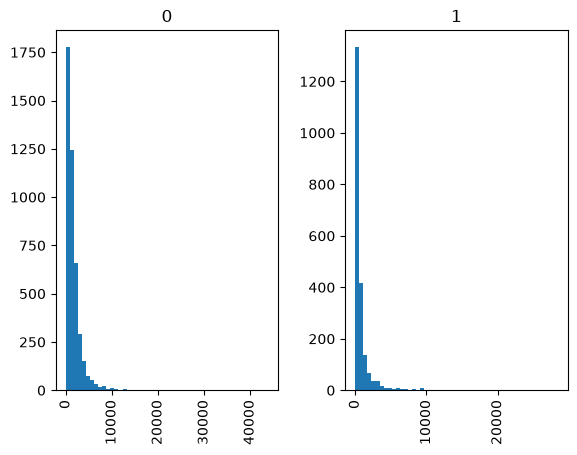

In [60]:
data['length'] = data['message'].map(lambda text: len(text))
data.hist(column='length', by='label', bins=50)

In [61]:
# train test split
data['label'] = pd.to_numeric(data['label'])
x_train, x_test, y_train, y_test = train_test_split(data.message, data.label, test_size=0.30)

In [62]:
x_train

3831    re : willow and pathstar evaluations  please r...
1099    big range of all types of downloadable softwar...
4479    re : i am zhendong  sure thing !  - - - - - or...
2758    re : trading algorithms  andy ,  sounds good ....
5378    re : thanksgiving staff meeting  hi clayton , ...
                              ...                        
656     you launched a website but no one visits it ? ...
4771    re : weather and energy price data  mulong wan...
124     enhance your anatomy  the longz system , both ...
6141    FREE UNLIMITED HARDCORE PORN direct 2 your mob...
60      partnership  mr . edward moko  18 independence...
Name: message, Length: 4532, dtype: str

In [63]:
data = pd.concat([data, df], ignore_index=True)
data['label'] = data['label'].astype(int)

In [64]:
## can also be used tfidf vectorizer instead of countvectorizer
cv = CountVectorizer()
x_train_count = cv.fit_transform(x_train.values)

In [65]:
x_train_count

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 509671 stored elements and shape (4532, 32716)>

In [66]:
x_train_count.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [4, 8, 0, ..., 0, 0, 0]], shape=(4532, 32716))

In [67]:
# train model
model = MultinomialNB()
model.fit(x_train_count, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3060.,1472.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.39,-1.12]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 32716)","[[1229., 311., 4.,..., 1., 2., 0.], [ 251., 415., 94.,..., 0., 0., 7.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 32716)","[[ -6.45, -7.82,-11.95,...,-12.87,-12.46,-13.56], [ -6.83, -6.33, -7.81,...,-12.36,-12.36,-10.28]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32716


In [68]:
#test model
x_test_count = cv.transform(x_test)
model.score(x_test_count, y_test)

0.9927946474523932

In [69]:
predicted=model.predict(x_test_count)

In [70]:
predicted

array([0, 0, 0, ..., 0, 0, 0], shape=(1943,))

In [71]:
print(metrics.classification_report(y_test,predicted))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1300
           1       0.99      0.99      0.99       643

    accuracy                           0.99      1943
   macro avg       0.99      0.99      0.99      1943
weighted avg       0.99      0.99      0.99      1943



Confusion Matrix:
[[ 634    9]
 [   5 1295]]


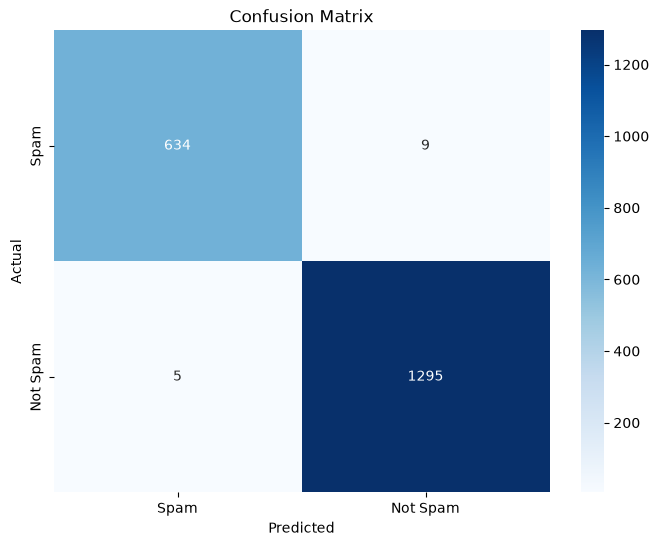

In [72]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, predicted, labels=[1, 0])

# Print confusion matrix
print("Confusion Matrix:")
print(cm)



import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Spam', 'Not Spam'], yticklabels=['Spam', 'Not Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Test the Result with different email.

In [73]:
sample_emails = [
    "Hi, are we still meeting for lunch at 1 pm today?",
    "Your electricity bill is due tomorrow. Please use the official payment portal.",
    "Congratulations! You have won $1,000,000. Call now to claim your prize.",
    "URGENT: You have been selected for a free vacation. Text WIN to 80000 now!",
    "Can you send me the notes from today's class?",
    "Free entry in a weekly competition to win a cash prize. Reply WIN now!"
]

sample_email_count = cv.transform(sample_emails)
sample_predictions = model.predict(sample_email_count)

pd.DataFrame({
    "email": sample_emails,
    "prediction": ["spam" if prediction == 1 else "ham" for prediction in sample_predictions]
})

,email,prediction
0,"Hi, are we still meeting for lunch at 1 pm today?",ham
1,Your electricity bill is due tomorrow. Please ...,ham
2,"Congratulations! You have won $1,000,000. Call...",spam
3,URGENT: You have been selected for a free vaca...,spam
4,Can you send me the notes from today's class?,ham
5,Free entry in a weekly competition to win a ca...,spam
